In [5]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

In [6]:
# Step 2: Load Data
# Load IMDb dataset (built into Keras)
vocab_size = 10000  # Use top 10,000 words
maxlen = 200  # Maximum sequence length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Training samples: {len(x_train)}")
print(f"Testing samples: {len(x_test)}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 52s 3us/step
Training samples: 25000
Testing samples: 25000


In [7]:

# Step 3: Pad Sequences
# Ensure all sequences have the same length
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post')

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


In [8]:
# Step 4: Build LSTM Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Step 5: Train the Model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 207ms/step - accuracy: 0.6255 - loss: 0.6089 - val_accuracy: 0.6264 - val_loss: 0.5982
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.7728 - loss: 0.4929 - val_accuracy: 0.6500 - val_loss: 0.5995
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.7738 - loss: 0.4725 - val_accuracy: 0.7698 - val_loss: 0.5205
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.8289 - loss: 0.4143 - val_accuracy: 0.6532 - val_loss: 0.6863
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.7563 - loss: 0.4657 - val_accuracy: 0.7850 - val_loss: 0.5385
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.8446 - loss: 0.3689 - val_accuracy: 0.7732 - val_loss: 0.5912
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.8297 - loss: 0.3935 - val_accuracy: 0.8012 - val_loss: 0.5135
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.8787 - loss: 0

In [12]:
# Step 6: Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8280 - loss: 0.4309

Test Accuracy: 82.80%
Test Loss: 0.4309


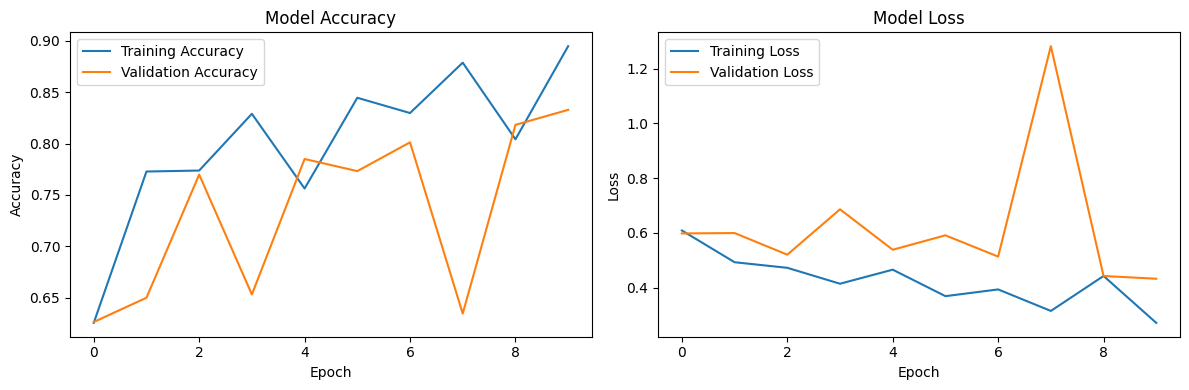

In [13]:
# Step 7: Plot Training History
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Step 8: Prediction Function
def predict_sentiment(text):
    # Load and fix IMDb word index (IMPORTANT)
    word_index = imdb.get_word_index()
    word_index = {k: (v + 3) for k, v in word_index.items()}
    word_index["<PAD>"] = 0
    word_index["<START>"] = 1
    word_index["<UNK>"] = 2

    # Preprocess input text
    words = text.lower().split()
    sequence = [word_index.get(word, 2) for word in words]  # 2 = <UNK>
    sequence = [w for w in sequence if w < vocab_size]

    # Pad sequence
    padded = pad_sequences([sequence], maxlen=maxlen, padding='post')

    # Predict
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prediction >= 0.5 else "Negative"

    return sentiment, prediction

In [ ]:
model.save("lstm_sentiment_model.keras")

In [ ]:
# Step 9: Test Predictions

user_review = input("\nEnter your movie review: ")
sentiment, score = predict_sentiment(user_review)

print("\nSentiment:", sentiment)
print("Confidence Score:", round(score, 4))

# Step 10: Save Model
model.save('lstm_sentiment_model.h5')
print("\nModel saved as 'lstm_sentiment_model.h5'")